<a href="https://colab.research.google.com/github/mayjary/hashedBit_tasks/blob/main/AAM_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = datasets.load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9666666666666667


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

dataset = [
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread', 'butter']
]

df = pd.DataFrame(dataset)
df = df.stack().str.get_dummies()
df = df.groupby(level = 0).sum()

frequent = apriori(df, min_support=0.5, use_colnames=True)
rules = association_rules(frequent, metric='confidence', min_threshold=0.5)

print(frequent)
print(rules)

   support         itemsets
0     0.75          (bread)
1     0.75         (butter)
2     0.75           (milk)
3     0.50  (butter, bread)
4     0.50    (milk, bread)
5     0.50   (butter, milk)
  antecedents consequents  antecedent support  ...  jaccard  certainty  kulczynski
0    (butter)     (bread)                0.75  ...      0.5  -0.333333    0.666667
1     (bread)    (butter)                0.75  ...      0.5  -0.333333    0.666667
2      (milk)     (bread)                0.75  ...      0.5  -0.333333    0.666667
3     (bread)      (milk)                0.75  ...      0.5  -0.333333    0.666667
4    (butter)      (milk)                0.75  ...      0.5  -0.333333    0.666667
5      (milk)    (butter)                0.75  ...      0.5  -0.333333    0.666667

[6 rows x 14 columns]


In [ ]:
import numpy as np

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0,0,0,1])

weights = np.zeros(2)
lr = 0.1
bias = 0

for _ in range(10):
  for i in range(len(X)):
    linear = np.dot(X[i], weights) + bias
    pred = 1 if linear > 0 else 0
    error = y[i] - pred

    weights += lr * error * X[i]
    bias += lr * error

print(weights, bias)

[0.2 0.1] -0.2


In [ ]:
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

data = datasets.load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Perceptron()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7666666666666667


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv = nn.Conv2d(3,16,3)
    self.pool = nn.MaxPool2d(2,2)
    self.fc = nn.Linear(16*15*15, 10)

  def forward(self, x):
    x = self.pool(torch.relu(self.conv(x)))
    x = x.view(-1, 16*15*15)
    x = self.fc(x)
    return x

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(1):
  for images, labels in trainloader:
    output = model(images)
    loss = criterion(output, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Finished")

Finished


In [ ]:
import torch

x = torch.tensor([1,0,2,0,3,0])
y = torch.tensor([2,0,4,0,6,0])

w = torch.tensor(0.0, requires_grad=True)

for epoch in range(10):
  y_pred = w * x
  loss = ((y_pred - y)**2).mean()
  loss.backward()

  with torch.no_grad():
    w -= 0.01 * w.grad

  w.grad.zero_()

print(w.item())

0.7598398327827454


In [ ]:
from itertools import combinations

dataset = (
    {'milk', 'bread'},
    {'milk', 'butter'},
    {'bread', 'butter'},
    {'milk', 'bread', 'butter'}
)

items = set.union(*dataset)

for i in range(1, len(items)+1):
  for combo in combinations(items, i):
    count = sum(1 for trans in dataset if set(combo).issubset(trans))
    support = count / len(dataset)

    if support >= 0.5:
      print(combo, ':', support)

('butter',) : 0.75
('bread',) : 0.75
('milk',) : 0.75
('butter', 'bread') : 0.5
('butter', 'milk') : 0.5
('bread', 'milk') : 0.5


In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances

X = np.array([[2,6],[3,4],[3,8],[4,7],[6,2],[7,3],[7,4],[8,5]])

# Initialize medoids randomly
medoids = [0, 4]

for _ in range(5):
    distances = pairwise_distances(X, X[medoids])
    labels = np.argmin(distances, axis=1)

    for i in range(len(medoids)):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            dist = pairwise_distances(cluster_points, cluster_points)
            medoids[i] = np.argmin(dist.sum(axis=1))

print("Medoids:", X[medoids])
print("Labels:", labels)

Medoids: [[7 4]
 [3 8]]
Labels: [0 0 0 0 0 0 0 0]


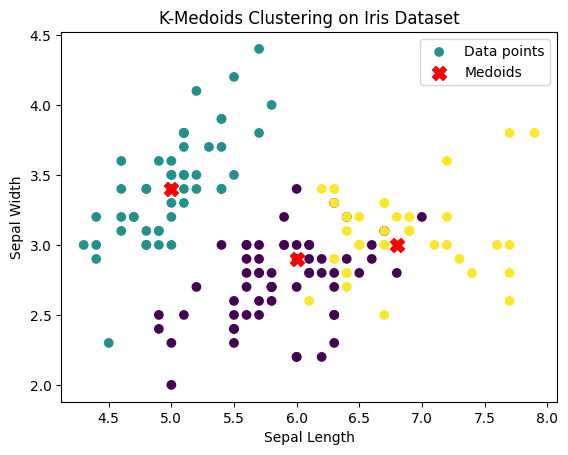

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from kmedoids import KMedoids
from sklearn.metrics import pairwise_distances
iris = load_iris()
X = iris.data

D = pairwise_distances(X, metric='euclidean')

kmedoids = KMedoids(n_clusters=3, random_state=42, metric='precomputed')
labels = kmedoids.fit_predict(D)

medoid_indices = kmedoids.medoid_indices_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', label='Data points')
plt.scatter(
    X[medoid_indices, 0],
    X[medoid_indices, 1],
    c='red', marker='X', s=100, label='Medoids')

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Medoids Clustering on Iris Dataset")
plt.legend()
plt.show()

In [ ]:
pip install kmedoids

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.3/476.3 kB 7.7 MB/s eta 0:00:00
